# Lab 9 — Capacity-Approaching Codes: LDPC and Polar

**Companion to Chapter 15** (*Turbo, LDPC and Polar Codes*).
**Time needed:** about 75 minutes. **Difficulty:** advanced.

5G NR uses LDPC codes for user data and polar codes for control information; Wi-Fi, DVB-S2 and
10GBASE-T use LDPC too. Both families come within about a decibel of the Shannon limit at
practical lengths, and both are decoded by passing soft messages along a graph. This lab builds
both from scratch (`commlib/coding.py`) so you can inspect every message.

### What you will learn
1. Construct an LDPC code by progressive edge growth (PEG) and check its Tanner graph for short cycles.
2. Decode with belief propagation (sum-product) and normalised min-sum; study iterations.
3. See why longer blocks give steeper waterfalls.
4. Watch channel polarization happen and choose a polar code's information set.
5. Compare SC with CRC-aided successive-cancellation list (CA-SCL) decoding.

### Prerequisites
Lab 8 (capacity, CRCs, soft decoding), Lab 2 (LLRs). Chapter 15.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | An LDPC code and its Tanner graph | |
| 2 | Belief propagation: BER and FER | |
| 3 | Block length and the waterfall | |
| 4 | Iterations and early stopping | yes |
| 5 | Channel polarization | |
| 6 | SC versus CRC-aided SC list decoding | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=9, lab="09")

def bpsk_llr(cw, ebn0_db, rate, r=rng):
    """Channel LLRs for BPSK (0 -> +1) at the given Eb/N0 and code rate."""
    sigma = np.sqrt(1 / (2 * rate * 10 ** (ebn0_db / 10)))
    y = (1 - 2 * cw.astype(float)) + sigma * r.standard_normal(len(cw))
    return 2 * y / sigma ** 2

Lab 09 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 9


## 1. An LDPC code and its Tanner graph

$\mathbf{H}$ is sparse: here every variable node (column) has degree 3 and every check node (row)
degree about 6, a (3,6)-regular ensemble of rate $1 - 3/6 = 1/2$. Belief propagation is exact on
a tree; short cycles in the Tanner graph make messages reinforce themselves. The shortest
possible cycle has length 4 (two checks sharing two variables). **PEG** construction adds edges
one at a time, each time connecting to the check node that is *farthest* from the variable in
the current graph, which maximises the local girth.

property,value
n (code length),576
k (information bits),288
rate,0.500
edges,1728
pairs of checks sharing ≥ 2 variables (4-cycles),0


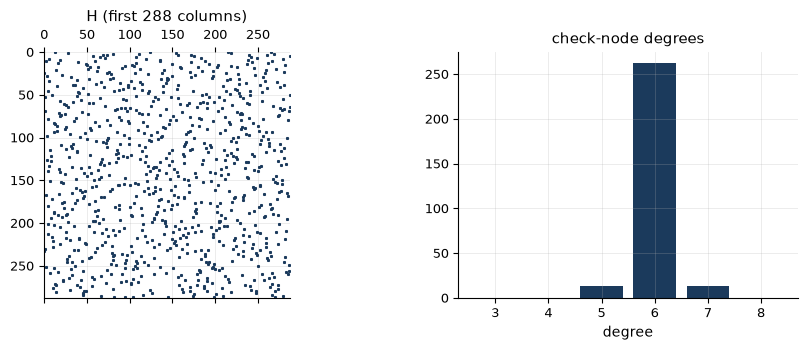

In [3]:
code = cl.LDPCCode(n=576, rate=0.5, dv=3, seed=3)
Hm = code.H.astype(int)
overlap = Hm @ Hm.T
np.fill_diagonal(overlap, 0)
four_cycles = int((overlap > 1).sum() // 2)
lk.table([["n (code length)", code.n], ["k (information bits)", code.k], ["rate", f"{code.rate:.3f}"],
          ["edges", code.E], ["pairs of checks sharing ≥ 2 variables (4-cycles)", four_cycles]],
         ["property", "value"], title="LDPC (576, 288) built by PEG")
f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [2, 1]})
ax[0].spy(code.H[:, :288], markersize=1.2, color=lk.NAVY); ax[0].set_title("H (first 288 columns)")
ax[1].hist(code.H.sum(axis=1), bins=np.arange(3, 10) - 0.5, rwidth=0.8, color=lk.NAVY)
ax[1].set_title("check-node degrees"); ax[1].set_xlabel("degree")
lk.show(f)

**What you should see.** A random-looking sparse matrix, check degrees concentrated at 6, and
zero 4-cycles.

### Try it yourself 1.1
An LDPC ensemble has variable degree 4 and check degree 12. What is its design rate?

In [5]:
answer_1_1 = None
lk.check("1.1 design rate of the (4,12) ensemble", answer_1_1, 1 - 4 / 12, atol=1e-3)

[TODO] 1.1 design rate of the (4,12) ensemble: not attempted yet: replace the None with your answer

## 2. Belief propagation: BER and FER

Each iteration, variable nodes send their current belief minus what they heard from each check,
and each check node answers with

$$r_{c\to v} = 2\tanh^{-1}\prod_{v'\ne v}\tanh\frac{q_{v'\to c}}{2}\quad\text{(sum-product)},\qquad
r_{c\to v} \approx \alpha\prod_{v'\ne v}\mathrm{sign}(q_{v'\to c})\,\min_{v'\ne v}|q_{v'\to c}|\quad\text{(min-sum)}.$$

Min-sum is over-confident; scaling by $\alpha \approx 0.8$ fixes most of the loss. Hardware
decoders (including 5G basebands) use layered normalised or offset min-sum.

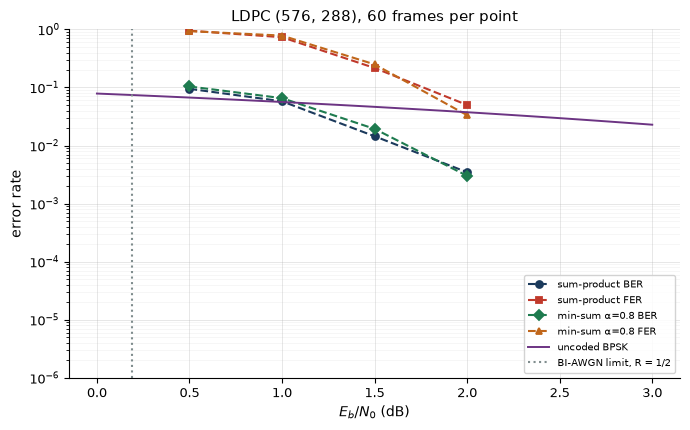

In [7]:
def ldpc_curve(c, ebn0s, method="minsum", frames=60, iters=50, seed0=1000):
    ber, fer = [], []
    for e in ebn0s:
        be = fe = 0
        for f_ in range(frames):
            r = np.random.default_rng(seed0 + f_)
            u = cl.random_bits(c.k, r)
            ch = c.decode(bpsk_llr(c.encode(u), e, c.rate, r), iters=iters, method=method)
            ne = np.sum(c.info_bits(ch) != u)
            be += ne; fe += ne > 0
        ber.append(be / (frames * c.k)); fer.append(fe / frames)
    return np.array(ber), np.array(fer)

eb = np.arange(0.5, 3.1, 0.5)
sims = {}
for m, lab in [("spa", "sum-product"), ("minsum", "min-sum α=0.8")]:
    b, fr = ldpc_curve(code, eb, m)
    sims[f"{lab} BER"], sims[f"{lab} FER"] = b, fr
ebf = np.linspace(0, 3, 100)
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb, sims, {"uncoded BPSK": cl.ber_bpsk(ebf)}, x_theory=ebf, ylabel="error rate", ylim=(1e-6, 1))
ax.axvline(0.19, color=lk.GRAY, ls=":", label="BI-AWGN limit, R = 1/2")
ax.legend(fontsize=7.5); ax.set_title("LDPC (576, 288), 60 frames per point")
lk.show(f)

**What you should see.** A "waterfall": FER drops from near 1 to a few percent within about
1.5 dB, with sum-product and scaled min-sum within a few tenths of a dB of each other. A regular
(3,6) code of this length reaches FER $10^{-2}$ near 2.5 dB, about 2.3 dB from the limit; the
irregular, optimised codes of NR and DVB-S2 do much better. (With only 60 frames per point
the lowest FERs are coarse: 1/60 is the smallest non-zero value.)

### Try it yourself 2.1
A check node receives the messages $q = [+2.0, -0.5, +1.5, +3.0]$. What does *unscaled*
($\alpha = 1$) min-sum send back to the **first** variable?

In [9]:
answer_2_1 = None
q = np.array([2.0, -0.5, 1.5, 3.0])
lk.check("2.1 min-sum message to variable 0", answer_2_1, np.prod(np.sign(q[1:])) * np.min(np.abs(q[1:])), atol=1e-6)

[TODO] 2.1 min-sum message to variable 0: not attempted yet: replace the None with your answer

## 3. Block length and the waterfall

The capacity theorem is asymptotic in block length. At short lengths the decoder cannot average
over enough noise and the waterfall is shallow; longer codes approach the limit more closely.
NR base graph 1 supports up to 8448 information bits per code block and operates within about
1 dB of capacity at FER $10^{-2}$.

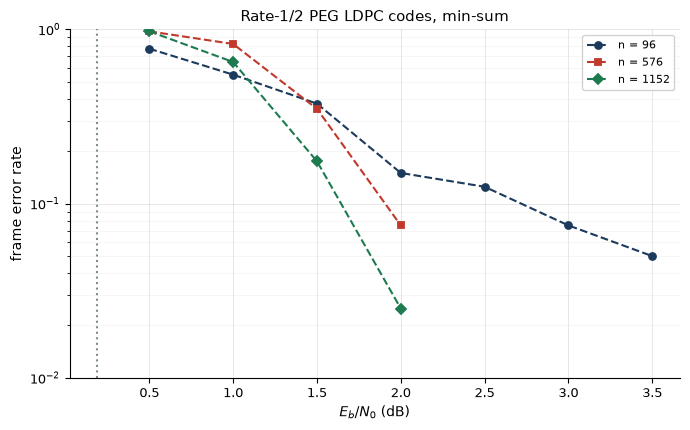

In [11]:
eb3 = np.arange(0.5, 4.1, 0.5)
fers = {}
for n in [96, 576, 1152]:
    cn = code if n == 576 else cl.LDPCCode(n=n, rate=0.5, dv=3, seed=1)
    fers[f"n = {n}"] = ldpc_curve(cn, eb3, "minsum", frames=40, seed0=3000)[1]
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb3, fers, ylabel="frame error rate", ylim=(1e-2, 1))
ax.axvline(0.19, color=lk.GRAY, ls=":"); ax.set_title("Rate-1/2 PEG LDPC codes, min-sum")
lk.show(f)

**What you should see.** The longer the code, the further left and the steeper its FER curve.

## 4. Iterations and early stopping

BP stops when the hard decisions satisfy every parity check ($\mathbf{H}\hat{\mathbf{c}}^T = 0$). At
good SNR most frames converge in a handful of iterations, so the *average* iteration count
(and the decoder's power) falls as the SNR rises, while the maximum sets the worst-case latency.

### Interactive

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

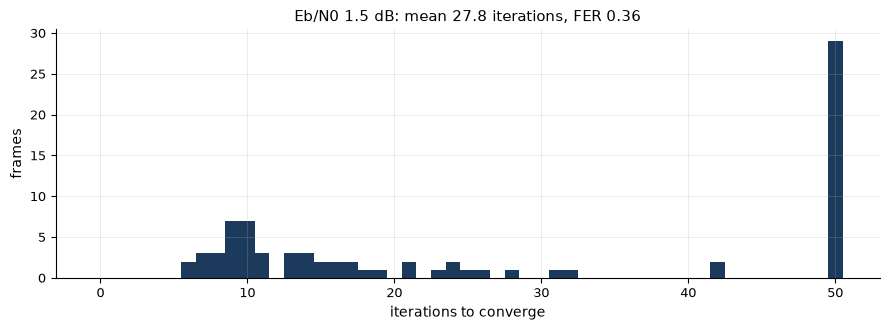

In [14]:
def iter_view(ebn0_db=1.5, method="minsum", max_iters=50):
    its, fails = [], 0
    for f_ in range(80):
        r = np.random.default_rng(f_)
        u = cl.random_bits(code.k, r)
        ch, it = code.decode(bpsk_llr(code.encode(u), ebn0_db, code.rate, r), iters=max_iters,
                             method=method, return_iters=True)
        its.append(it); fails += np.any(code.info_bits(ch) != u)
    f, ax = lk.fig("wide")
    ax.hist(its, bins=np.arange(0, max_iters + 2) - 0.5, color=lk.NAVY)
    ax.set_xlabel("iterations to converge"); ax.set_ylabel("frames")
    ax.set_title(f"Eb/N0 {ebn0_db} dB: mean {np.mean(its):.1f} iterations, FER {fails / 80:.2f}")
    lk.show(f)

lk.interact(iter_view, ebn0_db=lk.slider(1.5, 0, 4, 0.25, "Eb/N0 (dB)"),
            method=lk.choice(["minsum", "spa"], desc="decoder"), max_iters=lk.islider(50, 5, 100, 5, "max iterations"))

**What you should see.** At 1.5 dB most frames finish within about 5–15 iterations and a tail runs
to the maximum (those are usually the failures). Raise the SNR and the histogram piles up at 2–4.

## 5. Channel polarization

Arıkan's transform $\mathbf{G}_N = \mathbf{F}^{\otimes n}$, $\mathbf{F} = \begin{bmatrix}1&0\\1&1\end{bmatrix}$,
turns $N$ uses of a channel into $N$ synthetic bit-channels that are either nearly perfect or
nearly useless. For an erasure channel the Bhattacharyya parameter (erasure probability) evolves
exactly as $Z^- = 2Z - Z^2$ (worse) and $Z^+ = Z^2$ (better). Put information on the good channels,
freeze the bad ones to zero.

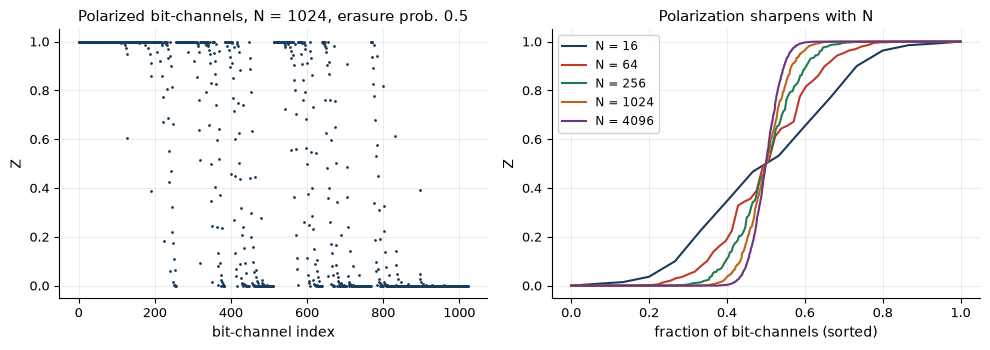

N = 1024: fraction with Z < 1e-3: 0.336; with Z > 1 - 1e-3: 0.336  (capacity = 0.5)


In [17]:
f, ax = lk.fig("row2", 1, 2)
Z = cl.PolarCode._bhat(1024, 0.5)
ax[0].plot(Z, ".", ms=2, color=lk.NAVY); ax[0].set_xlabel("bit-channel index"); ax[0].set_ylabel("Z")
ax[0].set_title("Polarized bit-channels, N = 1024, erasure prob. 0.5")
for n_ in [16, 64, 256, 1024, 4096]:
    Zn = np.sort(cl.PolarCode._bhat(n_, 0.5))
    ax[1].plot(np.linspace(0, 1, n_), Zn, label=f"N = {n_}")
ax[1].set_xlabel("fraction of bit-channels (sorted)"); ax[1].set_ylabel("Z"); ax[1].legend()
ax[1].set_title("Polarization sharpens with N")
lk.show(f)
print(f"N = 1024: fraction with Z < 1e-3: {np.mean(Z < 1e-3):.3f}; with Z > 1 - 1e-3: {np.mean(Z > 1 - 1e-3):.3f}"
      "  (capacity = 0.5)")

**What you should see.** As $N$ grows the sorted curve approaches a step at 0.5: half the channels
become perfect, half useless, exactly the capacity of the erasure channel. The polarization is
slow, though: at $N = 1024$ a sizeable fraction is still "mediocre", which is why finite-length
polar codes need help (next section).

### Try it yourself 5.1
Apply one polarization step to an erasure channel with $Z = 0.3$. What is the average of
$Z^-$ and $Z^+$? (Polarization conserves capacity: compare with 0.3.)

In [19]:
answer_5_1 = None
lk.check("5.1 mean of Z- and Z+ for Z = 0.3", answer_5_1, ((2 * 0.3 - 0.09) + 0.09) / 2, atol=1e-6)

[TODO] 5.1 mean of Z- and Z+ for Z = 0.3: not attempted yet: replace the None with your answer

## 6. SC versus CRC-aided SC list decoding

Successive cancellation decodes bits one by one, each using the decisions before it. It is
capacity-achieving asymptotically but weak at practical lengths, because an early wrong decision
is never revisited. Keeping the $L$ most likely paths and letting a CRC choose among the survivors
(CA-SCL; Tal and Vardy, 2015) is what made polar codes competitive; NR control channels use lists
of about 8 with CRC-11 or CRC-24 (TS 38.212). Here: $N = 256$, $K = 128$ with CRC-11.

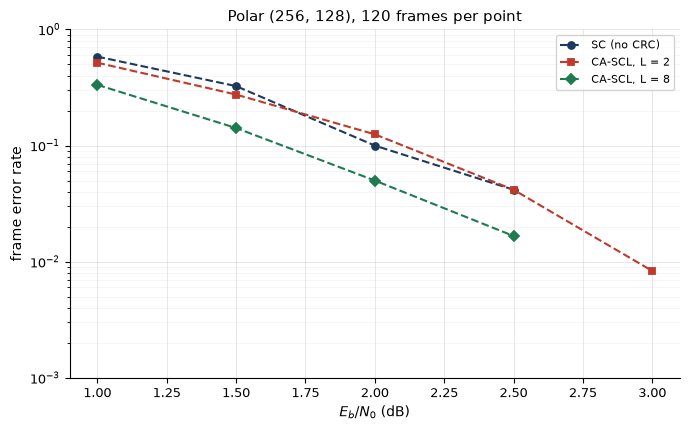

In [21]:
def polar_fer(ebn0s, L, frames=120, crc=True):
    pc = cl.PolarCode(256, 128, design_snr_db=2.0, crc_poly=cl.CRC11_5G if crc else None)
    out = []
    for e in ebn0s:
        fe = 0
        for f_ in range(frames):
            r = np.random.default_rng(5000 + f_)
            u = cl.random_bits(128, r)
            fe += not np.array_equal(pc.decode(bpsk_llr(pc.encode(u), e, 0.5, r), L=L), u)
        out.append(fe / frames)
    return np.array(out)

eb6 = np.arange(1.0, 3.6, 0.5)
fers = {"SC (no CRC)": polar_fer(eb6, 1, crc=False), "CA-SCL, L = 2": polar_fer(eb6, 2),
        "CA-SCL, L = 8": polar_fer(eb6, 8)}
f, ax = lk.fig("ber")
lk.ber_plot(ax, eb6, fers, ylabel="frame error rate", ylim=(1e-3, 1))
ax.set_title("Polar (256, 128), 120 frames per point")
lk.show(f)

**What you should see.** CA-SCL with $L = 8$ is clearly best, about half a decibel ahead of plain
SC at FER $10^{-2}$ in this short run and more at lower FER (published results for these lengths
show about 1 dB at $10^{-3}$). With $L = 2$ the list gain barely pays for the 11 CRC bits, which
eat into the rate: the list must be long enough for the CRC to have good candidates to choose from.

## Key takeaways
* LDPC codes are sparse parity-check matrices decoded by message passing; PEG construction removes
  short cycles; min-sum is the hardware-friendly approximation.
* Block length steepens the waterfall; practical LDPC codes sit within about 1 dB of capacity.
* Polar codes turn $N$ channels into good and bad ones; SC decoding plus a list and a CRC makes them
  strong at short lengths (NR control channels).

## Going further (hardware: USRP B200 / GNU Radio)
* Replace the convolutional code in `gnuradio/gr05_coded_link.py` with `cl.LDPCCode(576)`:
  compute LLRs from the received soft symbols ($2y/\sigma^2$) and compare decoded BER with the K = 7
  code at the same SNR.
* GNU Radio's `gr-fec` module contains LDPC and polar encoders/decoders; compare their FER with this lab.

## Exercises
1. **(Warm-up)** Show that the sum-product check update equals sign × min in the limit of large LLRs.
2. **(Core)** Implement layered (row-by-row) min-sum scheduling and show it converges in roughly half
   the iterations of flooding.
3. **(Core)** Replace the Bhattacharyya construction with the NR reliability sequence (TS 38.212
   Table 5.3.1.2-1) and compare FER at N = 256.
4. **(Core)** Count 6-cycles in the PEG code (hint: use powers of the bipartite adjacency matrix)
   and compare with a randomly constructed (3,6) code.
5. **(Stretch)** Implement polar rate matching (puncturing and shortening per TS 38.212) for
   N = 256, E = 200, and measure the loss.

In [24]:
lk.summary()

[good] Lab 09 finished in 47.5 s. Self-checks: 0 passed, 0 failed, 3 still to do.